In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")


In [2]:
customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
tickets = pd.read_csv("data/support_tickets.csv")
web = pd.read_csv("data/web_events_snapshot.csv")
churn = pd.read_csv("data/churn_labels.csv")
campaign = pd.read_csv("data/intervention_history.csv")

In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "churn": churn,
    "campaign": campaign
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)
    print(df.info())

customers
(2400, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None
orders
(10009, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 no

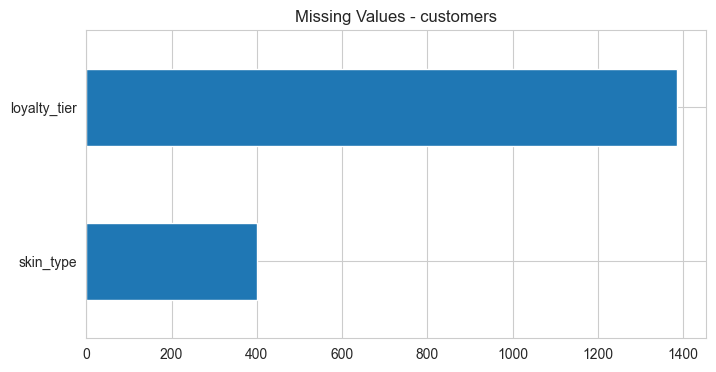

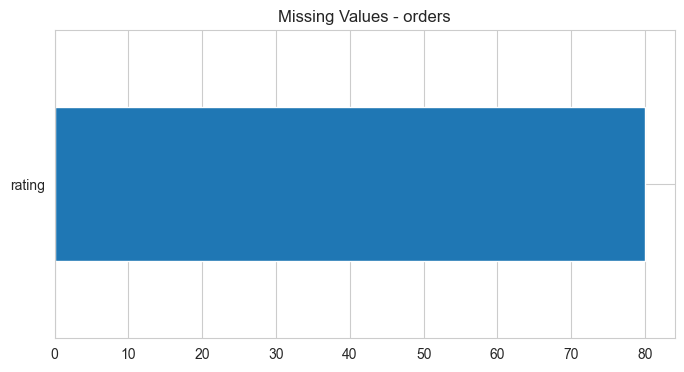

In [4]:
for name, df in datasets.items():

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) > 0:

        plt.figure(figsize=(8,4))

        missing.sort_values().plot(kind="barh")

        plt.title(f"Missing Values - {name}")

        plt.show()

In [5]:
dup_orders = orders[
    orders["order_id"].str.contains("_DUP", na=False)
]

print("Duplicate-like Orders")
print(dup_orders.shape)

dup_orders.head()

Duplicate-like Orders
(12, 10)


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


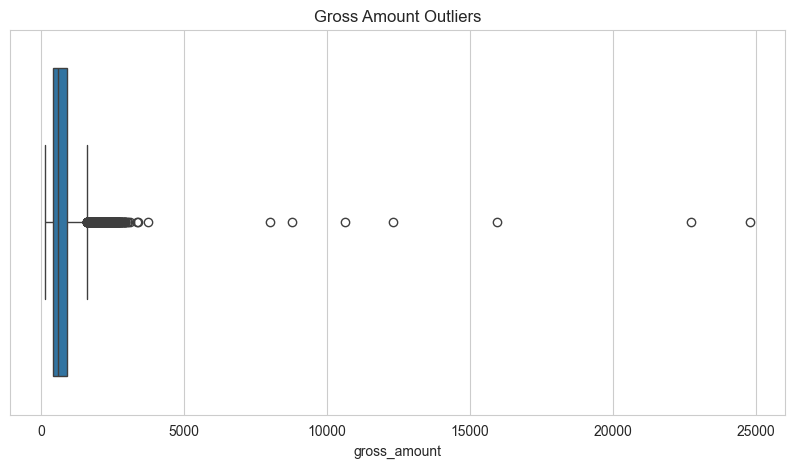

In [6]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title("Gross Amount Outliers")

plt.show()

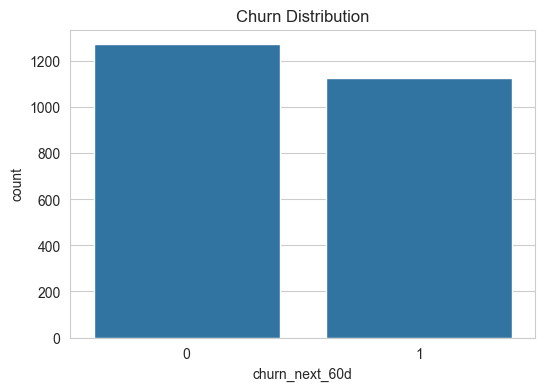

churn_next_60d
0    0.530417
1    0.469583
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="churn_next_60d",
    data=churn
)

plt.title("Churn Distribution")

plt.show()

print(
    churn["churn_next_60d"]
    .value_counts(normalize=True)
)

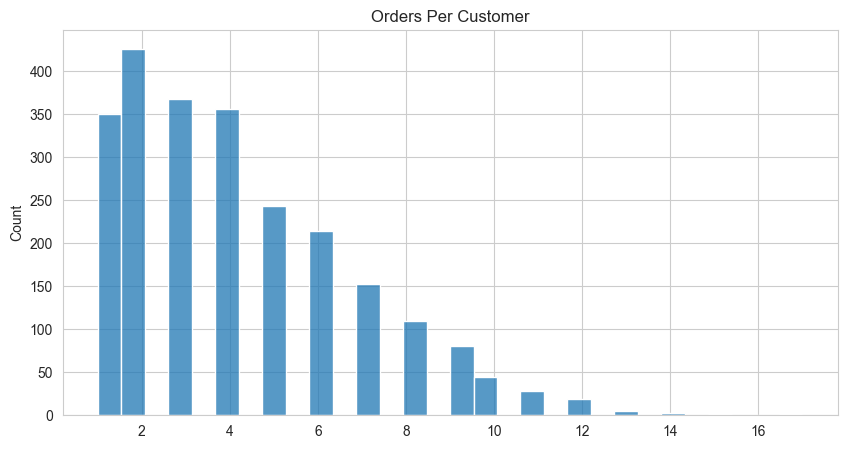

In [8]:
orders_per_customer = (
    orders.groupby("customer_id")
    .size()
)

plt.figure(figsize=(10,5))

sns.histplot(
    orders_per_customer,
    bins=30
)

plt.title("Orders Per Customer")

plt.show()

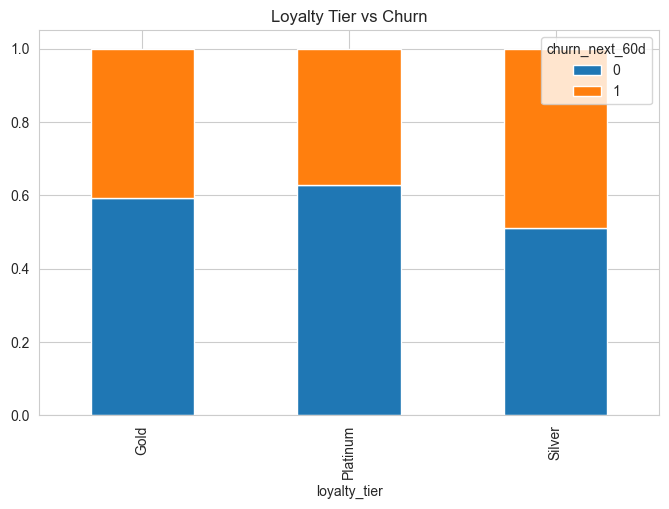

In [9]:
df = customers.merge(
    churn,
    on="customer_id"
)

loyalty_churn = pd.crosstab(
    df["loyalty_tier"],
    df["churn_next_60d"],
    normalize="index"
)

loyalty_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Loyalty Tier vs Churn")

plt.show()

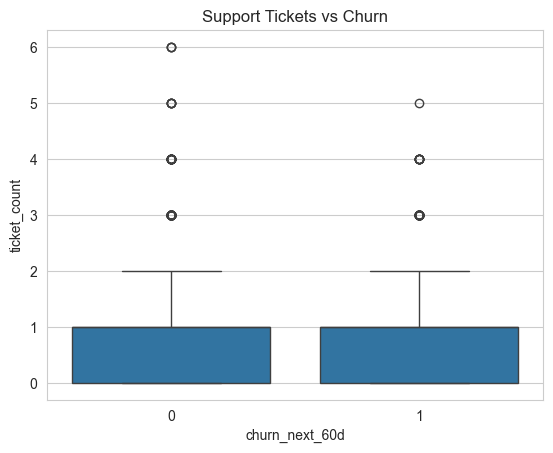

In [10]:
ticket_count = (
    tickets.groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)

temp = churn.merge(
    ticket_count,
    on="customer_id",
    how="left"
)

temp["ticket_count"] = (
    temp["ticket_count"]
    .fillna(0)
)

sns.boxplot(
    x="churn_next_60d",
    y="ticket_count",
    data=temp
)

plt.title(
    "Support Tickets vs Churn"
)

plt.show()

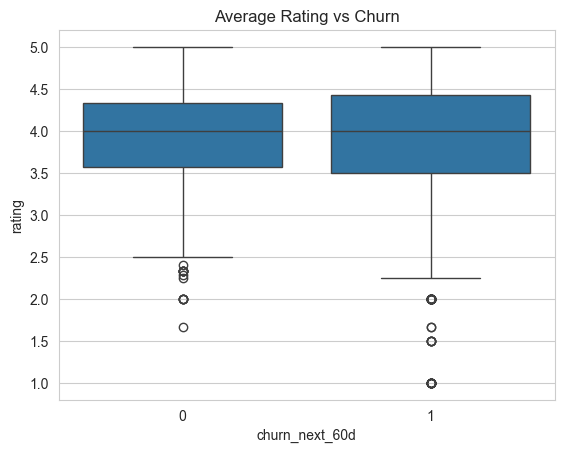

In [11]:
ratings = (
    orders.groupby("customer_id")["rating"]
    .mean()
    .reset_index()
)

temp = churn.merge(
    ratings,
    on="customer_id"
)

sns.boxplot(
    x="churn_next_60d",
    y="rating",
    data=temp
)

plt.title(
    "Average Rating vs Churn"
)

plt.show()

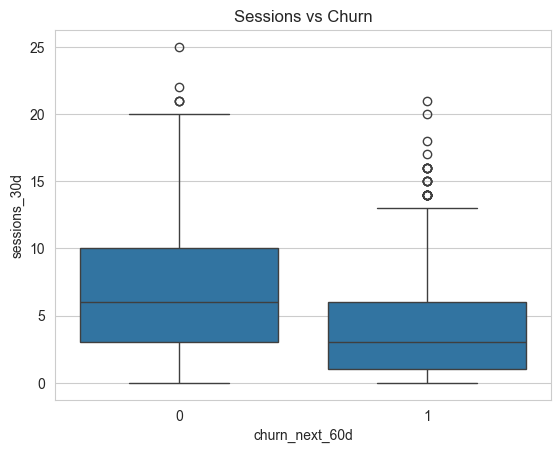

In [12]:
temp = web.merge(
    churn,
    on="customer_id"
)

sns.boxplot(
    x="churn_next_60d",
    y="sessions_30d",
    data=temp
)

plt.title(
    "Sessions vs Churn"
)

plt.show()

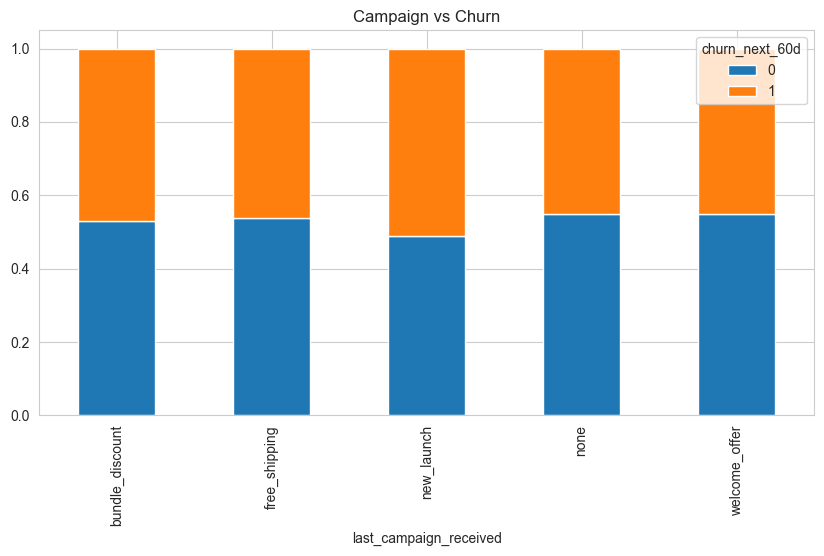

In [13]:
temp = campaign.merge(
    churn,
    on="customer_id"
)

campaign_table = pd.crosstab(
    temp["last_campaign_received"],
    temp["churn_next_60d"],
    normalize="index"
)

campaign_table.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title(
    "Campaign vs Churn"
)

plt.show()